# Re-analysis of the MIBI CRC TMA data – Glycolysis and proliferation

Next: 
* Find cell table including proliferation, glycolysis markers and lineage markers -> Re-export from (1)
* Run multiview MISTy
* Look at association between Ki67 and macrophage markers in cancer samples
* Compare to background in healthy sample

In [1]:
library(mistyR)
library(tidyverse)
library(future)
library(proxy)
library(withr)
library(igraph)
library(ggplot2)

mistyR is able to run computationally intensive functions
  in parallel. Please consider specifying a future::plan(). For example by running
  future::plan(future::multisession) before calling mistyR functions.

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘proxy’


The following objects are masked from ‘package:stats’:

    as.dist, dist


The following object is masked from ‘package:base’:

    as.matrix



Attaching package: ‘igraph’


The following objects are masked from ‘package:future’:

 

In [22]:
dataset <- read_csv("./data/cell_table_transformed.csv")
# dataset <- read_csv("./data/cell_table_with_types_stage.csv")
nrow(dataset)
names(dataset)
head(dataset)


New names:
• `` -> `...1`
Rows: 579947 Columns: 50
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): fov
dbl (49): ...1, SMA, CA9, nuclei, CD98, CytC, CD4, MSH2, FoxP3, MCT1, PDL1, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 579947

[1] "...1"              "SMA"               "CA9"              
 [4] "nuclei"            "CD98"              "CytC"             
 [7] "CD4"               "MSH2"              "FoxP3"            
[10] "MCT1"              "PDL1"              "CD31"             
[13] "PD1"               "ASCT2"             "CD7"              
[16] "LDH"               "CD163"             "STING1"           
[19] "DCN"               "CD68"              "GS"               
[22] "CD8"               "CD3e"              "GLS"              
[25] "MPO"               "ATP5A"             "CS"               
[28] "CD20"              "PKM2"              "GLUT1"            
[31] "HLADRa"            "CD14"              "CD45"             
[34] "PanCK"             "MSH6"              "ARG1"             
[37] "CPT1A"             "Vimentin"          "Ki67"             
[40] "membrane"          "centroid-0"        "centroid-1"       
[43] "eccentricity"      "perimeter"         "convex_area"      
[46] "area"              "axis_major_length" "axis_minor_length"
[49] "label"             "fov"

...1,SMA,CA9,nuclei,CD98,CytC,CD4,MSH2,FoxP3,MCT1,⋯,centroid-0,centroid-1,eccentricity,perimeter,convex_area,area,axis_major_length,axis_minor_length,label,fov
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0,1.340536e-04,0.02128943,0.04614832,0.006392956,0.01571343,8.352038e-03,0.02473370,0.023452892,0.0001934555,⋯,11.410959,5.593607,0.7726950,58.38478,237,219,21.38021,13.57168,1,A1a
1,2.969082e-03,0.01457781,0.03423819,0.008830998,0.10651270,1.744582e-03,0.06347377,0.001185208,0.0027742222,⋯,5.158590,29.418502,0.8454670,62.04163,241,227,23.90497,12.76592,2,A1a
2,1.187747e-05,0.11329879,0.06419776,0.034138213,0.01142891,7.277709e-05,0.06656348,0.000000000,0.0015064266,⋯,4.698324,47.871508,0.7962194,52.48528,186,179,19.81387,11.98755,3,A1a
3,4.471769e-06,0.12827739,0.09715288,0.040913454,0.03036816,8.118207e-04,0.01601639,0.001457594,0.0052802216,⋯,4.387283,64.393064,0.8625639,54.72792,185,173,21.77366,11.01634,4,A1a
4,1.260348e-04,0.10768224,0.05414692,0.070130227,0.09855133,2.678526e-03,0.08103716,0.001234451,0.0209243360,⋯,16.364760,75.551777,0.7414017,107.21930,742,647,35.80691,24.02864,5,A1a
5,2.138722e-04,0.10965646,0.01982199,0.026331486,0.06694059,2.292579e-03,0.02464267,0.000000000,0.0497367896,⋯,6.292818,118.911602,0.3705073,51.21320,195,181,16.19987,15.04692,6,A1a


In [14]:
# Load your transformed cell table
cells = read_csv("./data/cell_table_with_types_stage.csv")
head(cells)

New names:
• `` -> `...1`
Rows: 579011 Columns: 70
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (31): fov, annotation_t, annotation_scyan, consensus, annotation_consens...
dbl (37): ...1, CA9, nuclei, CD98, CytC, MSH2, MCT1, PDL1, PD1, ASCT2, LDH, ...
lgl  (2): Grade raw, pM group

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


...1,CA9,nuclei,CD98,CytC,MSH2,MCT1,PDL1,PD1,ASCT2,⋯,RAS Mutation RED,RAS Mutation RED 2,BRAF Mutation RED,HER2 Amplifikation,Age,Sex,MIBI,Tumor Size Group,Age Group,Stage
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
0,0.02128943,0.04614832,0.006392956,0.01571343,0.02473370,0.0001934555,0.009022579,0.004549611,0.04586374,⋯,NA,NA,NA,NA,88,w,acquired,NA,70 and Over,pT3
1,0.01457781,0.03423819,0.008830998,0.10651270,0.06347377,0.0027742222,0.004172783,0.000000000,0.02873399,⋯,NA,NA,NA,NA,88,w,acquired,NA,70 and Over,pT3
2,0.11329879,0.06419776,0.034138213,0.01142891,0.06656348,0.0015064266,0.009497505,0.000000000,0.02825994,⋯,NA,NA,NA,NA,88,w,acquired,NA,70 and Over,pT3
3,0.12827739,0.09715288,0.040913454,0.03036816,0.01601639,0.0052802216,0.022267382,0.028413114,0.03409141,⋯,NA,NA,NA,NA,88,w,acquired,NA,70 and Over,pT3
4,0.10768224,0.05414692,0.070130227,0.09855133,0.08103716,0.0209243360,0.004453675,0.022994452,0.11757625,⋯,NA,NA,NA,NA,88,w,acquired,NA,70 and Over,pT3
5,0.10965646,0.01982199,0.026331486,0.06694059,0.02464267,0.0497367896,0.001608107,0.027431549,0.19049839,⋯,NA,NA,NA,NA,88,w,acquired,NA,70 and Over,pT3


In [16]:
names(cells)

[1] "...1"                                  
 [2] "CA9"                                   
 [3] "nuclei"                                
 [4] "CD98"                                  
 [5] "CytC"                                  
 [6] "MSH2"                                  
 [7] "MCT1"                                  
 [8] "PDL1"                                  
 [9] "PD1"                                   
[10] "ASCT2"                                 
[11] "LDH"                                   
[12] "STING1"                                
[13] "DCN"                                   
[14] "GS"                                    
[15] "GLS"                                   
[16] "ATP5A"                                 
[17] "CS"                                    
[18] "PKM2"                                  
[19] "GLUT1"                                 
[20] "MSH6"                                  
[21] "ARG1"                                  
[22] "CPT1A"                                 
[23] "Vimentin"                              
[24] "Ki67"                                  
[25] "membrane"                              
[26] "centroid-0"                            
[27] "centroid-1"                            
[28] "eccentricity"                          
[29] "perimeter"                             
[30] "convex_area"                           
[31] "area"                                  
[32] "axis_major_length"                     
[33] "axis_minor_length"                     
[34] "label"                                 
[35] "fov"                                   
[36] "annotation_t"                          
[37] "annotation_scyan"                      
[38] "consensus"                             
[39] "annotation_consensus"                  
[40] "TMA name"                              
[41] "TMA sector"                            
[42] "Tumorlokalisation COL10"               
[43] "Tumorlokalisation alle RED"            
[44] "Tumor Seite alle"                      
[45] "Tumortyp"                              
[46] "pT raw"                                
[47] "pN raw"                                
[48] "Grade raw"                             
[49] "pT group"                              
[50] "pN group"                              
[51] "pM group"                              
[52] "Tumordurchmesser (mm)"                 
[53] "Muzinöse Tumorkomponente"              
[54] "Infiltrationstyp"                      
[55] "Tumorbudding"                          
[56] "Peritumorale lymphozytäre Infiltration"
[57] "Angioinvasion V RED"                   
[58] "Lymphbahninvasion L"                   
[59] "MSI im Befund"                         
[60] "MSI gesamt RED"                        
[61] "RAS Mutation RED"                      
[62] "RAS Mutation RED 2"                    
[63] "BRAF Mutation RED"                     
[64] "HER2 Amplifikation"                    
[65] "Age"                                   
[66] "Sex"                                   
[67] "MIBI"                                  
[68] "Tumor Size Group"                      
[69] "Age Group"                             
[70] "Stage"

In [3]:
# Exclude low epithelial abundance samples and SCT samples (start with "E1" or "E2")

# See StageXGB.ipynb
excluded_fovs = c('A2n','A3r','A4i','A5c','A7c','A7m','A8f','A9k','A9p','B1q','B2l',
                  'B2n','B3o','B4a','B4n','B5h','B5i','B5p','B6l','B7g','B7k','B7q',
                  'B8c','B9r','C2e','C9a','C9d','C9e','C9i','D1c','D1g','D2c','D3m',
                  'D4e','D6e','D6i','D7b','D8m','D9g','D9l')

cells <- cells %>% 
    filter(!(fov %in% excluded_fovs)) %>%
    filter(!grepl("^E[1-2]", fov))

In [13]:
paraview_l <- 120 # Distance in pixels up to which an effect will be considered in the paraview
juxtaview_l <- 40 # Distance in pixels up to which a cell is considered a direct neighbor
panel = c('PanCK', 'CD163', 'CD68', 'MCT1', 'LDH', 'GLUT1', 'Ki67')  # Markers to be used for the analysis
outputfile = "misty_colorectal_macro_prolif_multiview.sqm"

# Expected data is a list of tibbles with each one containing the marker expressions (columns) per cell (rows) for a fov
markers <- cells %>% group_by(fov) %>% select(all_of(panel)) %>% group_split(.keep = FALSE)

ERROR: [1m[33mError[39m in `select()`:[22m
[1m[22m[36mℹ[39m In argument: `all_of(panel)`.
[1mCaused by error in `all_of()`:[22m
[33m![39m Can't subset elements that don't exist.
[31m✖[39m Elements `PanCK`, `CD163`, and `CD68` don't exist.


In [5]:
# Coordinates of each cell
positions <- cells %>% group_by(fov) %>% select(c("centroid-0", "centroid-1")) %>% group_split(.keep = FALSE)

Adding missing grouping variables: `fov`


In [6]:
# Extract the names of the FOVs in the same order as the markers and positions tables
fov_names <- cells %>% group_by(fov) %>% summarise(fov = first(fov)) %>% pull(fov)

In [7]:
library(DBI)
library(RSQLite)
library(dplyr)

In [8]:
describe_sample_type <- function(dbfile, is_healthy = TRUE) {
  # Get all samples
  dbcon <- dbConnect(RSQLite::SQLite(), dbfile)
  samples <- dbGetQuery(dbcon, "SELECT DISTINCT sample FROM contributions") %>% 
    unlist()
  dbDisconnect(dbcon)
  
  # Create pattern based on sample type
  pattern <- if(is_healthy) {
    # Match E3 or E4 prefix
    paste0("(", paste0(
      grep("^(E3|E4)", samples, value = TRUE),
      collapse = "|"
    ), ")")
  } else {
    # Match anything not starting with E3 or E4
    paste0("(", paste0(
      grep("^(?!(E3|E4))", samples, value = TRUE, perl = TRUE),
      collapse = "|"
    ), ")")
  }
  
  # Collect filtered results
  collect_results(dbfile, pattern)
}

In [10]:
tumor_results <- describe_sample_type("./notebooks/spatial/misty_colorectal_metabolism_multiview.sqm", is_healthy = FALSE)








Aggregating



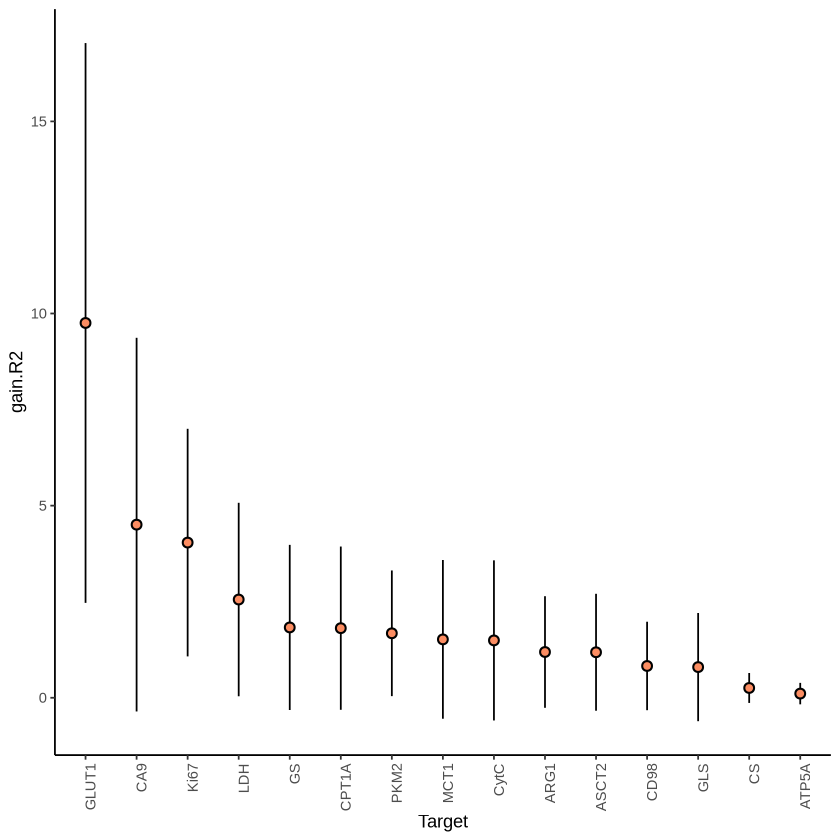

In [12]:
plot_improvement_stats(tumor_results)
